 # GitHub Repository Data Mining Pipeline

 This notebook/script crawls repository data from GitHub and visualizes it.

In [1]:
import json
import os
import time
import random as rd
from typing import List
import requests as rq
from datetime import datetime, timedelta
import math
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


 ## 1. Proxy Rotation

 Utility to rotate proxies for avoiding rate limits.

In [ ]:
class ProxyRotator:
    def __init__(self, proxies: list[str]):
        self.proxies = proxies
        self.current_proxy = None

    def get_next_proxy(self):
        if not self.proxies:
            return None

        if self.current_proxy is None:
            self.current_proxy = rd.choice(self.proxies)
        else:
            current_index = self.proxies.index(self.current_proxy)
            next_index = (current_index + 1) % len(self.proxies)
            self.current_proxy = self.proxies[next_index]

        return self.current_proxy

proxies: list[str] = [
    "62.133.63.236:1111",
    "212.34.141.109:5555",
    "210.223.44.230:3128",
    "175.99.220.171:80",
]
proxy_rotator = ProxyRotator(proxies)


 ## 2. GitHub API Client

 Main class to interface with GitHub's Search and Repository APIs.

In [4]:
class GitHubRepoApi:
    def __init__(self, token=None, proxies=None):
        self.base_url = "https://api.github.com"
        self.token = token

    def search_repos(
        self,
        languages: List[str],
        created_date: str,
        pushed_date: str,
        sort: str,
        order: str = "desc",
        page: int = 1,
        per_page: int = 100,
    ):
        url = f"{self.base_url}/search/repositories"

        languages_str = " ".join([f'language:"{lang}"' for lang in languages])

        query_parts = [
            languages_str,
            f"created:>={created_date}",
            f"pushed:<={pushed_date}"
        ]

        query = " ".join(query_parts)

        params = {
            "q": query,
            "sort": sort,
            "order": order,
            "page": page,
            "per_page": per_page,
        }

        headers = {
            "Accept": "application/vnd.github+json",
            "Authorization": f"token {self.token}" if self.token else None
        }

        try:
            response = rq.get(url, params=params, headers=headers)
            response.raise_for_status()

            result = response.json()

            total_count = result["total_count"]
            repositories = result["items"]
            has_next_page = (page * per_page) < total_count
            total_pages = math.ceil(total_count / per_page)
            timestamp = datetime.now().isoformat()
            metadata = {
                "timestamp": timestamp,
                "page": page,
                "per_page": per_page,
                "total_count": total_count,
                "has_next_page": has_next_page,
                "url": url,
                "query_params": query,
                "headers": headers,
                "total_pages": total_pages
            }

            return {
                "metadata": metadata,
                "repositories": repositories,
            }

        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in search_repositories: Status {response.status_code}, Response: {response.text}")
            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in search_repositories: {e}")
            return None

    def get_repo_languages(self, uri: str):
        if uri is None:
            print("Error: Uri is None")
            return None

        try:
            headers = {
                "Authorization": f"token {self.token}" if self.token else None
            }
            response = rq.get(uri, headers=headers)
            response.raise_for_status()

            result = response.json()

            return result
        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in get_repo_languages: Status {response.status_code}, Response: {response.text}")
            if response.status_code == 403:
                reset_time = response.headers.get('X-RateLimit-Reset')
                remaining = response.headers.get('X-RateLimit-Remaining')
                print(f'Remaining: {remaining}')
                if reset_time:
                    wait_seconds = int(reset_time) - int(time.time())
                    print(f'Rate limit exceeded. Resets in {wait_seconds} seconds.')
                else:
                    print('Rate limit exceeded. Please check your token.')

            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in get_repo_languages: {e}")
            return None

    def get_repo_tags(self, uri: str):
        if uri is None:
            print("Error: Uri is None")
            return None

        try:
            response = rq.get(uri)
            response.raise_for_status()

            result = response.json()

            return result
        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in get_repo_tags: Status {response.status_code}, Response: {response.text}")
            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in get_repo_tags: {e}")
            return None

    def get_repo_readme_contents(self, uri: str):
        if uri is None:
            print("Error: Uri is None")
            return None

        base = "README"
        readme_names = [''.join(p) + '.md' for p in product(*[(c.lower(), c.upper()) for c in base])]

        headers = {
            "Authorization": f"token {self.token}" if self.token else None
        }

        def try_readme(readme_name):
            try:
                current_uri = uri.replace("{+path}", readme_name)
                response = rq.get(
                    current_uri,
                    headers=headers
                )
                response.raise_for_status()
                result = response.json()
                return result
            except rq.exceptions.HTTPError as e:
                if response.status_code == 404:
                    return None
                elif response.status_code == 403:
                    reset_time = response.headers.get('X-RateLimit-Reset')
                    remaining = response.headers.get('X-RateLimit-Remaining')
                    print(f'Remaining: {remaining}')
                    if reset_time:
                        wait_seconds = int(reset_time) - int(time.time())
                        print(f'Rate limit exceeded. Resets in {wait_seconds} seconds.')
                    else:
                        print('Rate limit exceeded. Please check your token.')
                    raise
                else:
                    print(f"HTTP Error in get_repo_readme_contents for {readme_name}: Status {response.status_code}, Response: {response.text}")
                    return None
            except rq.exceptions.ProxyError as e:
                print(f"Proxy error: {e}")
                return None
            except rq.exceptions.RequestException as e:
                print(f"Request Error in get_repo_readme_contents for {readme_name}: {e}")
                return None

        with ThreadPoolExecutor(max_workers=10) as executor:
            futures = {executor.submit(try_readme, name): name for name in readme_names}
            for future in as_completed(futures):
                result = future.result()
                if result is not None:
                    for f in futures:
                        f.cancel()
                    return result

        print(f"No readme found for {uri}")
        return None

    def get_repo_contents(self, owner: str, repo: str, path: str = ""):
        base_url = f"{self.base_url}/repos/{owner}/{repo}/contents"
        url = f"{base_url}/{path}" if path else base_url

        headers = {
            "Accept": "application/vnd.github+json",
            "Authorization": f"token {self.token}" if self.token else None
        }

        try:
            response = rq.get(url, headers=headers)
            response.raise_for_status()

            result = response.json()

            return result

        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in get_repo_contents: Status {response.status_code}, Response: {response.text}")
            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in get_repo_contents: {e}")
            return None

    def get_repo_raw_content(self, url: str):
        if url is None:
            print("Error: Url is None")
            return None

        headers = {
            "Authorization": f"token {self.token}" if self.token else None
        }

        try:
            response = rq.get(url, headers=headers)
            response.raise_for_status()

            return response.text

        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in get_repo_raw_content: Status {response.status_code}, Response: {response.text}")
            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in get_repo_raw_content: {e}")
            return None

    def get_repo_commits(self, owner: str, repo: str):
        url = f"{self.base_url}/repos/{owner}/{repo}/commits"

        headers = {
            "Authorization": f"token {self.token}" if self.token else None
        }

        try:
            response = rq.get(url, headers=headers)
            response.raise_for_status()

            result = response.json()

            return result
        except rq.exceptions.HTTPError as e:
            print(f"HTTP Error in get_repo_commits: Status {response.status_code}, Response: {response.text}")
            if response.status_code == 403:
                reset_time = response.headers.get('X-RateLimit-Reset')
                remaining = response.headers.get('X-RateLimit-Remaining')
                print(f'Remaining: {remaining}')
                if reset_time:
                    wait_seconds = int(reset_time) - int(time.time())
                    print(f'Rate limit exceeded. Resets in {wait_seconds} seconds.')
                else:
                    print('Rate limit exceeded. Please check your token.')
            return None
        except rq.exceptions.RequestException as e:
            print(f"Request Error in get_repo_commits: {e}")
            return None


 ## 3. Processing Functions

 Functions to handle individual tasks like processing metadata, languages, etc.

In [ ]:
def process_repo_meta(
    language: str,
    page: int,
    github_crawler: GitHubRepoApi,
    created_date: str,
    pushed_date: str,
    max_retries: int,
    retry_delay: int
):
    filename = f"../data/github/repositories/github_repo_metadata_{language.lower().replace(' ', '_')}_{page}.json"
    if os.path.exists(filename):
        print(f"Skipping {language} page {page}, file already exists")
        return

    print(f"Processing {language} page {page}")

    result = None
    for attempt in range(max_retries):
        result = github_crawler.search_repos(
            languages=[language],
            created_date=created_date,
            pushed_date=pushed_date,
            sort="stars",
            page=page,
        )

        if result:
            break
        else:
            if attempt < max_retries - 1:
                print(f"Failed to fetch {language} page {page}, attempt {attempt+1}, retrying in {retry_delay}s")
                time.sleep(retry_delay)
            else:
                print(f"Failed to fetch {language} page {page} after {max_retries} attempts")
                result = None

    if result:
        with open(filename, "w") as f:
            json.dump(result, f, indent=4)
            print(f"Saved {language} page {page}")

        has_next_page = result["metadata"]["has_next_page"]
        if not has_next_page:
            print(f"No more pages for {language} after page {page}")
    else:
        print(f"Skipping to next after failed {language} page {page}")

    time.sleep(15)

def process_repo_languages(repo: dict, github_crawler: GitHubRepoApi):
    languages_url = repo["languages_url"]
    html_url = repo["html_url"]
    languages = github_crawler.get_repo_languages(languages_url)
    return {"html_url": html_url, "languages": languages} if languages else None

def process_repo_readme(repo: dict, github_crawler: GitHubRepoApi, max_retries: int, retry_delay: int):
    contents_url = repo["contents_url"]
    html_url = repo["html_url"]

    readme = None
    for attempt in range(max_retries):
        readme = github_crawler.get_repo_readme_contents(contents_url)

        if readme:
            break
        else:
            if attempt < max_retries - 1:
                print(f"Failed to fetch readme for {html_url}, attempt {attempt+1}, retrying in {retry_delay}s")
                time.sleep(retry_delay)
            else:
                print(f"Failed to fetch readme for {html_url} after {max_retries} attempts")

    return {"html_url": html_url, "readme": readme} if readme else None

def process_repo_contents(repo: dict, github_crawler: GitHubRepoApi):
    html_url = repo["html_url"]
    owner = html_url.split("/")[-2]
    repo_name = html_url.split("/")[-1]
    contents = github_crawler.get_repo_contents(owner, repo_name)
    return {"html_url": html_url, "contents": contents} if contents else None

def process_repo_commits(repo: dict, github_crawler: GitHubRepoApi, max_retries: int, retry_delay: int):
    html_url = repo["html_url"]
    owner = html_url.split("/")[-2]
    repo_name = html_url.split("/")[-1]

    commits = None
    for attempt in range(max_retries):
        commits = github_crawler.get_repo_commits(owner, repo_name)

        if commits:
            break
        else:
            if attempt < max_retries - 1:
                print(f"Failed to fetch commits for {html_url}, attempt {attempt+1}, retrying in {retry_delay}s")
                time.sleep(retry_delay)
            else:
                print(f"Failed to fetch commits for {html_url} after {max_retries} attempts")

    return {"html_url": html_url, "commits": commits} if commits else None


 ## 4. Crawling Pipeline

 Orchestration functions for different types of data.

In [ ]:
def crawl_repo_meta(github_crawler: GitHubRepoApi):
    languages = [
        "Python", "JavaScript", "Java", "C++", "C#",
        "Golang", "Rust", "TypeScript", "Swift", "Kotlin"
    ]
    years_back = 10
    created_date = (datetime.now() - timedelta(days=years_back * 365)).strftime("%Y-%m-%d")
    pushed_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

    os.makedirs("../data/github/repositories", exist_ok=True)

    max_pages = 10
    max_retries = 3
    retry_delay = 60

    tasks = []
    for page in range(1, max_pages + 1):
        for language in languages:
            tasks.append((language, page))

    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [executor.submit(process_repo_meta, lang, pg, github_crawler, created_date, pushed_date, max_retries, retry_delay) for lang, pg in tasks]
        for future in as_completed(futures):
            future.result()

def crawl_repo_languages(github_crawler: GitHubRepoApi):
    os.makedirs("../data/github/languages", exist_ok=True)
    repo_dir = "../data/github/repositories"
    if not os.path.exists(repo_dir): return
    files = [f for f in os.listdir(repo_dir) if f.endswith(".json")]

    for filename in files:
        languages_filename = filename.replace(".json", "_languages.json")
        languages_filepath = os.path.join("../data/github/languages", languages_filename)
        if os.path.exists(languages_filepath):
            continue

        with open(os.path.join(repo_dir, filename), "r") as f:
            repo_data = json.load(f)

        repos = repo_data["repositories"]

        with ThreadPoolExecutor(max_workers=10) as executor:
            futures = [executor.submit(process_repo_languages, repo, github_crawler) for repo in repos]
            languages_data = [future.result() for future in as_completed(futures) if future.result()]

        if languages_data:
            with open(languages_filepath, "w") as f:
                json.dump(languages_data, f, indent=4)

def sanitize_filename(filename: str) -> str:
    invalid_chars = '<>:"|?*\\'
    for char in invalid_chars:
        filename = filename.replace(char, '_')
    filename = filename.replace('"', '').replace("'", '')
    filename = ''.join(c for c in filename if c.isprintable() and c not in '\r\n\t')
    filename = filename.strip()
    return filename[:255] if filename else 'unnamed_file'

def download_and_save_file(github_crawler: GitHubRepoApi, url: str, base_dir: str, owner: str, repo_name: str, filename: str):
    safe_filename = sanitize_filename(filename)
    repo_dir = os.path.join(base_dir, owner, repo_name)
    os.makedirs(repo_dir, exist_ok=True)
    filepath = os.path.join(repo_dir, safe_filename)

    if os.path.exists(filepath): return

    content = github_crawler.get_repo_raw_content(url)
    if content is not None:
        with open(filepath, "w", encoding="utf-8") as f:
            f.write(content)

def crawl_repo_contents(github_crawler: GitHubRepoApi):
    os.makedirs("../data/github/contents", exist_ok=True)
    repo_dir = "../data/github/repositories"
    if not os.path.exists(repo_dir): return
    files = [f for f in os.listdir(repo_dir) if f.endswith(".json")]

    for filename in files:
        contents_filename = filename.replace(".json", "_contents.json")
        contents_filepath = os.path.join("../data/github/contents", contents_filename)
        if os.path.exists(contents_filepath): continue

        with open(os.path.join(repo_dir, filename), "r") as f:
            repo_data = json.load(f)

        repos = repo_data["repositories"]

        with ThreadPoolExecutor(max_workers=5) as executor:
            futures = [executor.submit(process_repo_contents, repo, github_crawler) for repo in repos]
            contents_data = [future.result() for future in as_completed(futures) if future.result()]

        if contents_data:
            with open(contents_filepath, "w") as f:
                json.dump(contents_data, f, indent=4)


 ## 5. Data Visualization

 Visualizing the crawled data using Pandas, Matplotlib and Seaborn.

In [2]:
def plot_github_data():
    repo_dir = "../data/github/repositories"
    if not os.path.exists(repo_dir):
        print("Data directory not found. Please run the crawl functions first.")
        return

    all_repos = []
    files = [f for f in os.listdir(repo_dir) if f.endswith(".json")]

    for filename in files:
        with open(os.path.join(repo_dir, filename), "r") as f:
            data = json.load(f)
            all_repos.extend(data.get("repositories", []))

    if not all_repos:
        print("No repository data found.")
        return

    df = pd.DataFrame(all_repos)

    # Preprocessing
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['year'] = df['created_at'].dt.year

    # 1. Distribution of repositories by primary language
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='language', order=df['language'].value_counts().index)
    plt.title('Number of Repositories by Primary Language')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Top 10 Most Starred Repositories
    plt.figure(figsize=(12, 6))
    top_starred = df.sort_values('stargazers_count', ascending=False).head(10)
    sns.barplot(data=top_starred, x='stargazers_count', y='full_name', hue='language')
    plt.title('Top 10 Most Starred Repositories')
    plt.tight_layout()
    plt.show()

    # 3. Stars Distribution by Language
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='language', y='stargazers_count')
    plt.yscale('log')
    plt.title('Stars Distribution by Language (Log Scale)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 4. Repositories created over the years
    plt.figure(figsize=(12, 6))
    df_yearly = df.groupby(['year', 'language']).size().reset_index(name='count')
    sns.lineplot(data=df_yearly, x='year', y='count', hue='language')
    plt.title('Repositories Created Over the Years')
    plt.tight_layout()
    plt.show()


 ## 6. Execution Pipeline

 Main entry point to run the crawler and visualizer.

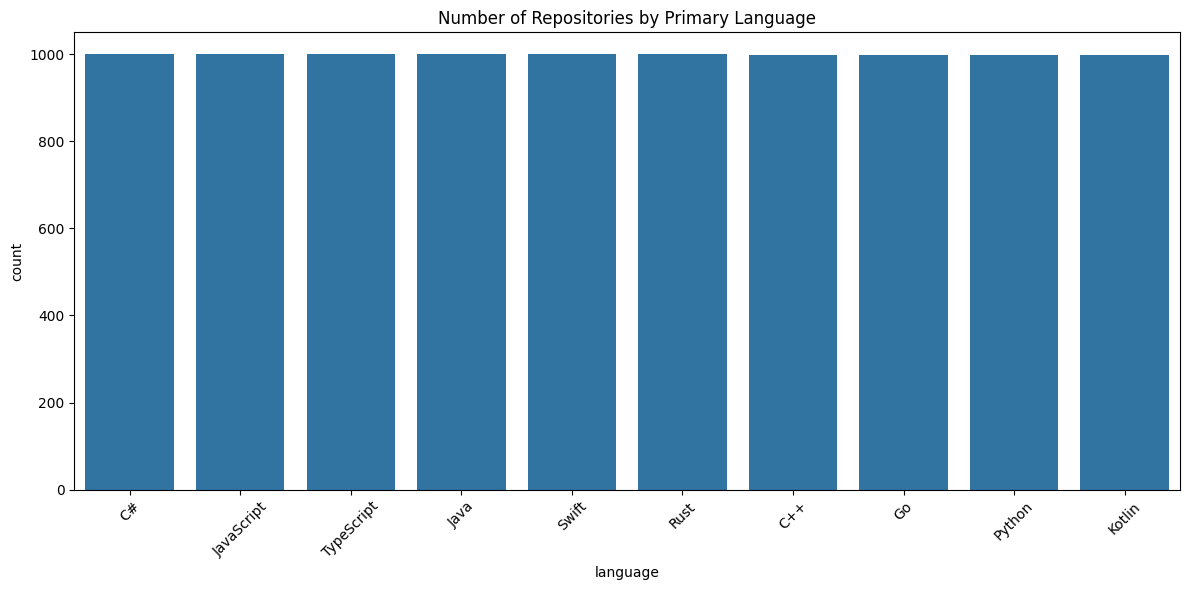

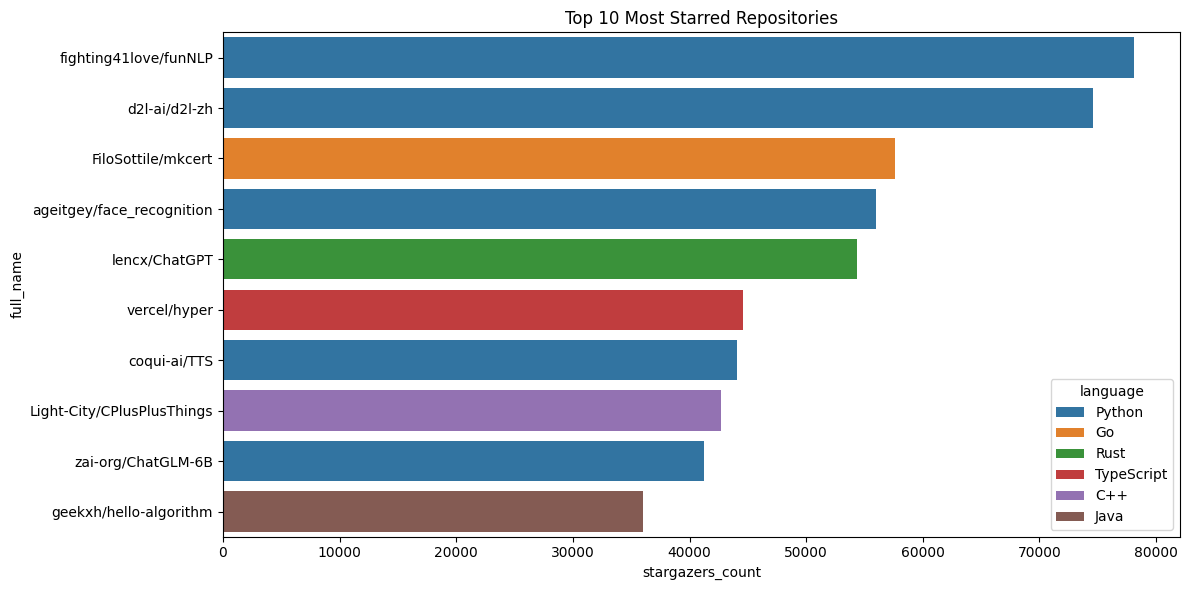

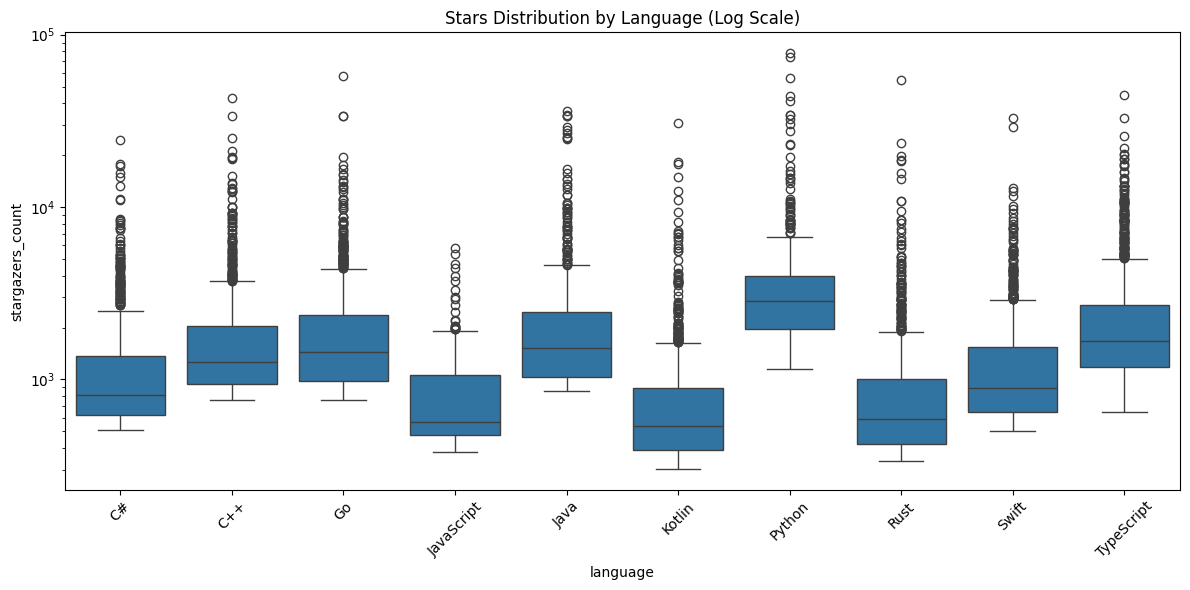

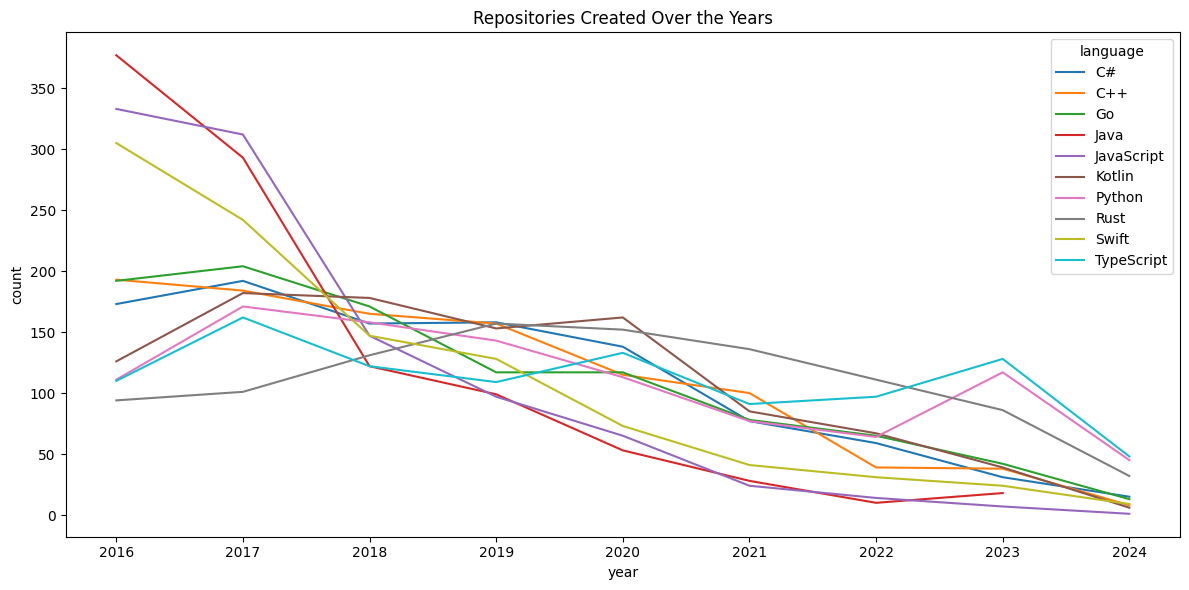

In [5]:
# Initialize API
TOKEN = os.getenv("GITHUB_TOKEN", None) # Use environment variable if available
github_repo_api = GitHubRepoApi(token=TOKEN)

# Note: These are commented out to prevent accidental large-scale crawling
# crawl_repo_meta(github_repo_api)
# crawl_repo_languages(github_repo_api)
# crawl_repo_contents(github_repo_api)

# Plot the results
plot_github_data()
